# Step 0: Install requirements.
# Tested with: PyTorch 2.x, CUDA 12.x, Pillow 10.x, Colab GPU runtime.

In [1]:
!nvidia-smi

Fri May 22 10:51:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   77C    P0             29W /   70W |   10795MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!git clone https://github.com/stylegan-human/StyleGAN-Human.git

fatal: destination path 'StyleGAN-Human' already exists and is not an empty directory.


In [3]:
# Install ninja (required for JIT compilation of CUDA extensions)
!pip install ninja -q

In [4]:
!pip install lpips

In [5]:
import pathlib, os, shutil

# 1. Clear stale CUDA extension cache from previous Colab sessions
cache = os.path.expanduser('~/.cache/torch_extensions')
if os.path.exists(cache):
    shutil.rmtree(cache)
    print('Cleared torch_extensions cache')

# 2. Fix custom_ops.py for PyTorch 2.x:
#    torch.utils.cpp_extension.load() no longer registers the module in sys.modules,
#    so importlib.import_module() raises 'No module named upfirdn2d_plugin'.
#    Fix: use the return value of load() directly.
for p in pathlib.Path('.').rglob('torch_utils/custom_ops.py'):
    text = p.read_text()
    fixed = text
    fixed = fixed.replace(
        '            torch.utils.cpp_extension.load(name=module_name, build_directory=build_dir,\n'
        '                verbose=verbose_build, sources=digest_sources, **build_kwargs)\n'
        '        else:\n'
        '            torch.utils.cpp_extension.load(name=module_name, verbose=verbose_build, sources=sources, **build_kwargs)\n'
        '        module = importlib.import_module(module_name)',
        '            module = torch.utils.cpp_extension.load(name=module_name, build_directory=build_dir,\n'
        '                verbose=verbose_build, sources=digest_sources, **build_kwargs)\n'
        '        else:\n'
        '            module = torch.utils.cpp_extension.load(name=module_name, verbose=verbose_build, sources=sources, **build_kwargs)'
    )
    fixed = fixed.replace(
        '            torch.utils.cpp_extension.load(name=module_name, build_directory=cached_build_dir,\n'
        '                verbose=verbose_build, sources=cached_sources, **build_kwargs)\n'
        '        else:\n'
        '            torch.utils.cpp_extension.load(name=module_name, verbose=verbose_build, sources=sources, **build_kwargs)\n'
        '\n'
        '        # Load.\n'
        '        module = importlib.import_module(module_name)',
        '            module = torch.utils.cpp_extension.load(name=module_name, build_directory=cached_build_dir,\n'
        '                verbose=verbose_build, sources=cached_sources, **build_kwargs)\n'
        '        else:\n'
        '            module = torch.utils.cpp_extension.load(name=module_name, verbose=verbose_build, sources=sources, **build_kwargs)'
    )
    if fixed != text:
        p.write_text(fixed)
        print(f'Patched custom_ops.py: {p}')
    else:
        print(f'Already patched or pattern mismatch: {p}')

# 3. Fix PIL.Image.ANTIALIAS -> LANCZOS (removed in Pillow 10.0)
for p in pathlib.Path('.').rglob('*.py'):
    try:
        text = p.read_text()
        if 'ANTIALIAS' in text:
            p.write_text(text.replace('PIL.Image.ANTIALIAS', 'PIL.Image.LANCZOS')
                            .replace('Image.ANTIALIAS', 'Image.LANCZOS'))
            print(f'Fixed ANTIALIAS: {p}')
    except Exception:
        pass

# 4. Fix op_edit C++ sources for PyTorch 2.x:
#    - Tensor::type().is_cuda() removed -> use is_cuda() directly
#    - ATen/cuda/CUDAApplyUtils.cuh removed in PyTorch 2.0
for p in pathlib.Path('.').rglob('torch_utils/op_edit/*.cpp'):
    text = p.read_text()
    fixed = text.replace('x.type().is_cuda()', 'x.is_cuda()')
    if fixed != text:
        p.write_text(fixed)
        print(f'Fixed Tensor::type() in: {p}')

for p in pathlib.Path('.').rglob('torch_utils/op_edit/*.cu'):
    lines = p.read_text().splitlines(keepends=True)
    clean = [l for l in lines if 'CUDAApplyUtils.cuh' not in l]
    if len(clean) != len(lines):
        p.write_text(''.join(clean))
        print(f'Removed CUDAApplyUtils.cuh from: {p}')

print('Done.')


Cleared torch_extensions cache
Already patched or pattern mismatch: StyleGAN-Human/torch_utils/custom_ops.py
Already patched or pattern mismatch: User-Whole-Body-Generation/StyleGAN_Human/torch_utils/custom_ops.py
Already patched or pattern mismatch: User-Whole-Body-Generation/PTI/torch_utils/custom_ops.py
Fixed Tensor::type() in: StyleGAN-Human/torch_utils/op_edit/upfirdn2d.cpp
Fixed Tensor::type() in: StyleGAN-Human/torch_utils/op_edit/fused_bias_act.cpp
Fixed Tensor::type() in: User-Whole-Body-Generation/StyleGAN_Human/torch_utils/op_edit/upfirdn2d.cpp
Fixed Tensor::type() in: User-Whole-Body-Generation/StyleGAN_Human/torch_utils/op_edit/fused_bias_act.cpp
Removed CUDAApplyUtils.cuh from: StyleGAN-Human/torch_utils/op_edit/upfirdn2d_kernel.cu
Removed CUDAApplyUtils.cuh from: StyleGAN-Human/torch_utils/op_edit/fused_bias_act_kernel.cu
Removed CUDAApplyUtils.cuh from: User-Whole-Body-Generation/StyleGAN_Human/torch_utils/op_edit/upfirdn2d_kernel.cu
Removed CUDAApplyUtils.cuh from: Use

# Step1: Download pretrained models.

In [ ]:
import os
repo_name='StyleGAN-Human'
os.chdir(f'./{repo_name}')

In [ ]:
def get_download_model_command(file_id, file_name):
    """Download a model from Google Drive using gdown and save to pretrained_models/."""
    current_directory = os.getcwd()
    save_path = os.path.join(os.path.dirname(current_directory), f'{repo_name}', "pretrained_models")
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    # &confirm=t bypasses the Google Drive virus-scan warning page
    url = f'gdown "https://drive.google.com/uc?id={file_id}&confirm=t" -O "{save_path}/{file_name}"'
    return url

In [ ]:
MODEL_PATHS = {
    "stylegan1_1024": {"id": "1h-R-IV-INGdPEzj4P9ml6JTEvihuNgLX", "name": "stylegan1_1024.pkl"},
    "stylegan2_1024": {"id": "1FlAb1rYa0r_--Zj_ML8e6shmaF28hQb5", "name": "stylegan2_1024.pkl"},
    "stylegan2_512": {"id": "1dlFEHbu-WzQWJl7nBBZYcTyo000H9hVm", "name": "stylegan2_512.pkl"},
    "stylegan3_512": {"id": "1_274jk_N6WSCkKWeu7hjHycqGvbuOFf5", "name": "stylegan3_512.pkl"},
    # "stylegan3_1024": {"id": None, "name": "stylegan3_1024.pkl"},
    # "stylegan1_512": {"id": None, "name": "stylegan1_512.pkl"},
}

In [ ]:
#@title Select which experiment you wish to perform inference on: { run: "auto" }
experiment_type = 'stylegan2_1024' #@param ['stylegan1_1024', 'stylegan2_1024', 'stylegan1_512', 'stylegan2_512', 'stylegan3_512']

In [10]:
path = MODEL_PATHS[experiment_type]
download_command = get_download_model_command(file_id=path["id"], file_name=path["name"])
!{download_command}

Downloading...
From (original): https://drive.google.com/uc?id=1FlAb1rYa0r_--Zj_ML8e6shmaF28hQb5
From (redirected): https://drive.google.com/uc?id=1FlAb1rYa0r_--Zj_ML8e6shmaF28hQb5&confirm=t&uuid=009f4909-6e51-4b63-b362-5379e647906a
To: /content/StyleGAN-Human/pretrained_models/stylegan2_1024.pkl
100% 362M/362M [00:11<00:00, 31.0MB/s] 


# Step2: Generate full-body images using different models.


In [ ]:
version=experiment_type.split("_")[0][-1] 
version

'2'

In [12]:
!python generate.py --outdir=outputs/{experiment_type}/ --seeds=4-10 --trunc=0.7 --network=pretrained_models/{experiment_type}.pkl --version {version}

Loading networks from "pretrained_models/stylegan2_1024.pkl"...
Setting up PyTorch plugin "bias_act_plugin"... Done.
Setting up PyTorch plugin "upfirdn2d_plugin"... Done.
/content/StyleGAN-Human/generate.py:109: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  PIL.Image.fromarray(img[0].cpu().numpy(), 'RGB').save(f'{outdir}/seed{seed:04d}.png')
/content/StyleGAN-Human/generate.py:109: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  PIL.Image.fromarray(img[0].cpu().numpy(), 'RGB').save(f'{outdir}/seed{seed:04d}.png')
/content/StyleGAN-Human/generate.py:109: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  PIL.Image.fromarray(img[0].cpu().numpy(), 'RGB').save(f'{outdir}/seed{seed:04d}.png')
/content/StyleGAN-Human/generate.py:109: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  PIL.Image.f

# Step3: Visualize

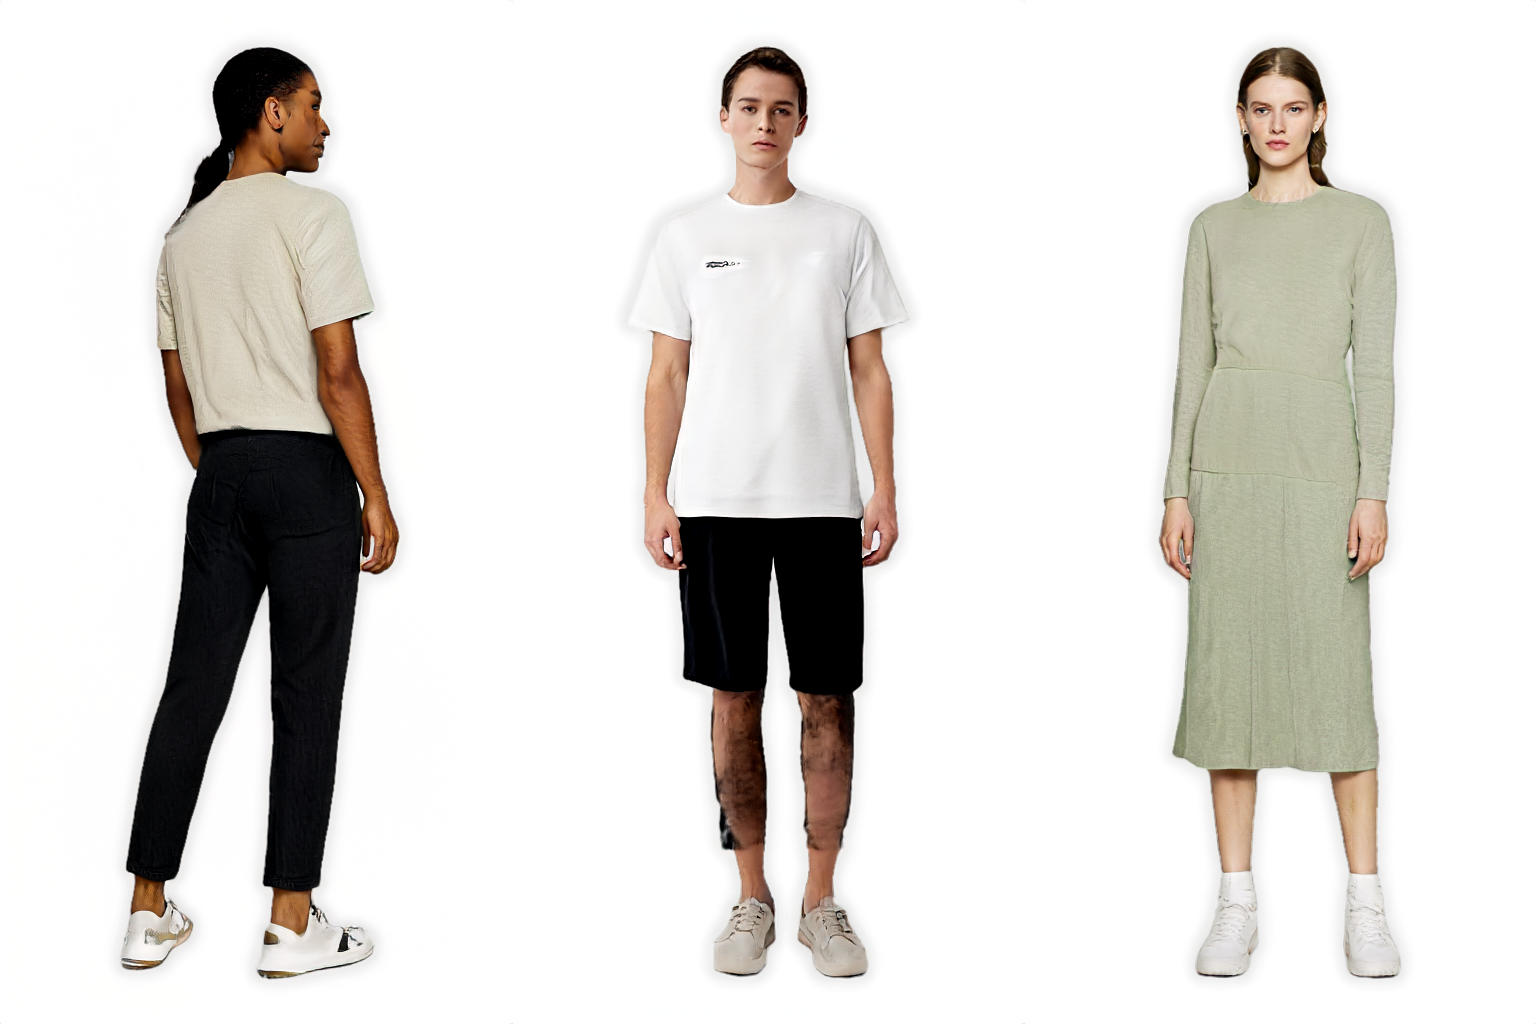

In [13]:
from PIL import Image
import cv2
import numpy as np
output_images = [os.path.join(f"outputs/{experiment_type}", x) for x in os.listdir(f"outputs/{experiment_type}")]
sample_images = output_images[:3]
for idx, image_path in enumerate(sample_images):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    if idx == 0:
        res = image
    else:
        res = np.concatenate([res, image], axis=1)

res = Image.fromarray(res)
res

# Application 1: Editing & Style-mixing:

# **Upper Length**

In [14]:
# editing
#'upper_length' or 'bottom_length'
!python edit.py --outdir outputs/editing --network pretrained_models/stylegan2_1024.pkl --attr_name upper_length --seeds 61531,61570,61571,61610 



start...


# **Bottom Length :**

In [15]:
!python edit.py --outdir outputs/editing --network pretrained_models/stylegan2_1024.pkl --attr_name bottom_length --seeds 61531,61570,61571,61610 

start...


# **Style Mixing :**

In [16]:
# style-mixing
!python style_mixing.py --outdir=outputs/stylemixing --rows=85,100,75,458,1500,86 --cols=55,821,1789,293,75 --network=pretrained_models/stylegan2_1024.pkl --styles=0-3  


Loading networks from "pretrained_models/stylegan2_1024.pkl"...
Generating W vectors...
Setting up PyTorch plugin "bias_act_plugin"... Done.
Generating images...
Setting up PyTorch plugin "upfirdn2d_plugin"... Done.
Generating style-mixed images...
Saving image grid...
/content/StyleGAN-Human/style_mixing.py:98: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  canvas.paste(PIL.Image.fromarray(image_dict[key], 'RGB'), (W * col_idx, H * row_idx))


# Application 2: InsetGAN (use StyleGAN2-FFHQ as face generator):

In [17]:
## Download pretrained StyleGAN on FFHQ 1024x1024 and dlib models.

# ffhq.pkl: downloaded directly from NVIDIA CDN (more reliable than Drive)
!wget -q --show-progress \
    https://nvlabs-fi-cdn.nvidia.com/stylegan2-ada-pytorch/pretrained/ffhq.pkl \
    -O pretrained_models/ffhq.pkl

# dlib face detector and landmark predictor
dlib_detector = get_download_model_command(file_id="1MduBgju5KFNrQfDLoQXJ_1_h5MnctCIG", file_name='mmod_human_face_detector.dat')
dlib_landmark = get_download_model_command(file_id="1A82DnJBJzt8wI2J8ZrCK5fgHcQ2-tcWM", file_name='shape_predictor_68_face_landmarks.dat')
!{dlib_detector}
!{dlib_landmark}

pretrained_models/f 100%[===================>] 363.94M  10.3MB/s    in 20s     
Downloading...
From: https://drive.google.com/uc?id=1MduBgju5KFNrQfDLoQXJ_1_h5MnctCIG
To: /content/StyleGAN-Human/pretrained_models/mmod_human_face_detector.dat
100% 730k/730k [00:00<00:00, 126MB/s]
Downloading...
From: https://drive.google.com/uc?id=1A82DnJBJzt8wI2J8ZrCK5fgHcQ2-tcWM
To: /content/StyleGAN-Human/pretrained_models/shape_predictor_68_face_landmarks.dat
100% 99.7M/99.7M [00:06<00:00, 14.4MB/s]


In [ ]:
# Perform joint optimization and generate seamless images
!python insetgan.py --face_seed=9 --body_seed=89180 \
                    --joint_steps=500 --outdir outputs/insetgan --video 1

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
face: 24.0000, lr: 0.0006184665997806832, loss: 180.89, loss_coarse: 24.45;loss_border: 87.57, loss_face: 68.86;: 100% 25/25 [00:08<00:00,  2.88it/s]
body: 149.0000, lr: 8.767851876239353e-05, loss: 205.70, loss_coarse: